# Simulations light inter

In [1]:
from __future__ import annotations

import os
import sys
from datetime import date
import numpy as np

from scipy.interpolate import splev, splrep

sys.path.append("../data") 
from archi_dict import archi_sorghum as archi
# from oawidgets.plantgl import *  # noqa: F403

from openalea.archicrop.display import build_scene, display_scene  # noqa: F401
from openalea.archicrop.simulation import (
    compute_pot_growth,
    param_sampling,
)
from openalea.archicrop.viability import resolve_organ_growth
from openalea.plantgl.all import Color3, Material, Scene, Viewer  # noqa: F401

%gui qt

In [2]:
stics_color = "orange"
archicrop_color = "green"

In [3]:
seed = 18

In [4]:
n_samples = 6

param_sets = param_sampling(archi_params=archi, n_samples=n_samples, seed=seed, latin_hypercube=False)

daily_dynamics = {i:{"Thermal time": t, "Phenology": 'juvenile' if t < 300 else 'exponential' if t < 900 else 'repro'} 
                  for i,t in enumerate(range(0,1000,20))}

pot_la, pot_h, mtgs = compute_pot_growth(param_sets, daily_dynamics)

In [5]:
# ### Plot the 3D scene
# times = [t for i,t in enumerate(thermal_time) if i%10==0]
# mean_time = sum(times) / len(times)
# positions = [ (1*(t-mean_time), 0, 0) for t in times]
# nice_green = Color3((40, 80, 0))
# scene, _ = build_scene(
#     [g for i,g in enumerate(mtgs[id]) if i%10==0], 
#     position=positions, 
#     senescence=True, 
#     leaf_material = Material(nice_green), 
#     stem_material=Material(nice_green))
# display_scene(scene)

In [6]:
from openalea.plantgl.all import Color3, Material, Scene, Viewer
from datetime import date

today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True)  # noqa: PTH103
# plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/plot_extin_coef_LAI_{parameter_name}.png")

nice_green = Color3((40, 80, 0))

for id,mtg in mtgs.items():
    Viewer.display(build_scene(mtg, senescence=True, leaf_material = Material(nice_green), stem_material=Material(nice_green))[0])
    Viewer.grids.setXYPlane(False)
    Viewer.grids.setYZPlane(False)
    Viewer.grids.setXZPlane(False)
    Viewer.camera.lookAt((386.117,-232.613,435.8), (0,0,100))
    Viewer.frameGL.saveImage(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/sorghum_{params_sets[id]['phyllochron']}_{params_sets[id]['rmax']}_{params_sets[id]['insertion_angle']}_{params_sets[id]['curvature']}.png")

NameError: name 'params_sets' is not defined

In [ ]:
# g_direct = {id: mtg for id,mtg in mtgs.items()}
# g_direct[0].property("azimuth")

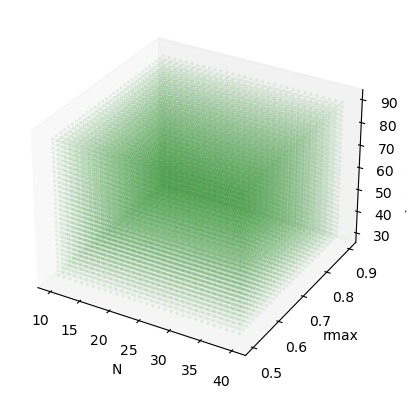

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Example parameter space
p1 = np.arange(10, 41)
p2 = np.linspace(0.5, 0.9, len(p1))
p3 = np.linspace(30, 90, len(p1))

P1, P2, P3 = np.meshgrid(p1, p2, p3)

fig = plt.figure() # (constrained_layout=True, figsize=(8, 6))
# plt.subplots_adjust(left=0.1, right=0.85, bottom=0.1, top=0.9)
ax = fig.add_subplot(projection='3d')

ax.scatter(P1.ravel(), P2.ravel(), P3.ravel(), s=3, color='green', alpha=0.05)

ax.set_xlabel("N")
ax.set_ylabel("rmax")
ax.set_zlabel("insertion angle")
# ax.zaxis.set_label_coords(-0.1, 0.5)

ax.grid(False)
today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True) 
plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/morphospace_theoretical.png")
plt.show()


In [2]:
def compute_phi(nb_phy, end_veg, ligul_factor=1.6):
    phyllochron = (end_veg)/(nb_phy - 1 + ligul_factor)
    return phyllochron

def compute_rmax(nb_phy, end_veg, index_end_veg, thermal_time, leaf_area_plant, ligul_factor=1.6):
    phyllochron = compute_phi(nb_phy, end_veg, ligul_factor)
    ligulochron = phyllochron * ligul_factor
    
    leaf_area_plant = leaf_area_plant[:index_end_veg+2]
    thermal_time = thermal_time[:index_end_veg+2]
    spl = splrep(thermal_time, leaf_area_plant)
    
    starts = []
    ends = []
    
    for i in range(nb_phy):
        start = i * phyllochron 
        end = start + ligulochron
        
        starts.append(start)
        ends.append(end)
    
    la_starts = splev(starts, spl)
    la_ends = splev(ends, spl)
    
    leaf_areas = resolve_organ_growth(nb_phy, ligul_factor, la_ends)
       
    for i, la in enumerate(leaf_areas):
        if la == max(leaf_areas):
            id_max = i+1
            break
    
    rmax_int = np.arange(max(0,(id_max-1)/nb_phy), min(1,(id_max+1)/nb_phy), 0.01)
    
    # leaf_areas_norm = [la/max(leaf_areas) for la in leaf_areas]
    
    # skews_rmax = {}
    # id = 0
    # for rank in range(1, nb_phy+1):
    #     for rmax in rmax_int:
    #         if rmax != rank/nb_phy and leaf_areas[rank-1] > 0:
    #             skew = compute_skew(rank=rank, nb_phy=nb_phy, rmax=rmax, leaf_areas=leaf_areas_norm)
    #             if 1e-10 < skew < 1.0:
    #                 skews_rmax[id] = (skew, rmax)
    #                 id += 1
    
    # skew_int = []
    # for id,(skew,rmax) in skews_rmax.items():
    #     bell_shaped_leaf_areas = bell_shaped_dist(leaf_area_plant[-1]*pot_factor, nb_phy, rmax, skew)
    #     for i,bs in enumerate(bell_shaped_leaf_areas):
    #         if bs < leaf_areas[i]:
    #             break
    #         else:
    #             skew_int.append(skew)

    return rmax_int # id_max/nb_phy 

In [3]:
from openalea.archicrop.stics_io import read_sti_file, get_stics_data

def stics_output(tec_file, plant_file, stics_output_file):
    """Extract relevant data from STICS output files."""

    density, daily_dynamics, lifespan, lifespan_early, inter_row = get_stics_data(
        file_tec_xml=tec_file,  # Path to the STICS management XML file
        file_plt_xml=plant_file,  # Path to the STICS plant XML file
        stics_output_file=stics_output_file  # Path to the STICS output file
    )

    thermal_time = [value["Thermal time"] for value in daily_dynamics.values()]
    leaf_area_plant = [value["Plant leaf area"] for value in daily_dynamics.values()]
    sen_leaf_area_plant = [value["Plant senescent leaf area"] for value in daily_dynamics.values()]
    height_canopy = [value["Plant height"] for value in daily_dynamics.values()]

    for key, value in daily_dynamics.items():
        if value["Phenology"] == 'juvenile':
            next_key = key + 1
            if next_key in daily_dynamics and daily_dynamics[next_key]["Phenology"] == 'exponential':
                end_juv = thermal_time[key-1] + thermal_time[0]

        elif value["Phenology"] == 'exponential':
            next_key = key + 1
            if next_key in daily_dynamics and daily_dynamics[next_key]["Phenology"] == 'repro':
                end_veg = thermal_time[key-1] + thermal_time[0]
                index_end_veg = key - 1
                break

    return density, daily_dynamics, lifespan, lifespan_early, thermal_time, leaf_area_plant, sen_leaf_area_plant, height_canopy, end_juv, end_veg, index_end_veg

tec_file='D:/ArchiCrop/data/02NT18SorgV2D1_tec.xml'
plant_file='D:/ArchiCrop/data/sorgho_imp_M_v10_plt.xml'
stics_output_file='D:/ArchiCrop/data/mod_s02NT18SorgV2D1.sti'
stics_output_file_pot='D:/ArchiCrop/data/mod_s02NT18SorgV2D1_no_stress.sti'

density, daily_dynamics, lifespan, lifespan_early, thermal_time, leaf_area_plant, sen_leaf_area_plant, height_canopy, end_juv, end_veg, index_end_veg = stics_output(tec_file, plant_file, stics_output_file)
density_pot, daily_dynamics_pot, lifespan_pot, lifespan_early_pot, thermal_time_pot, leaf_area_plant_pot, sen_leaf_area_plant_pot, height_canopy_pot, end_juv_pot, end_veg_pot, index_end_veg_pot = stics_output(tec_file, plant_file, stics_output_file_pot)


[0.73913043 0.74913043 0.75913043 0.76913043 0.77913043 0.78913043
 0.79913043 0.80913043 0.81913043]


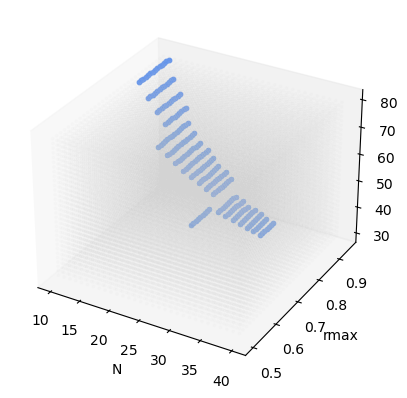

In [6]:
import numpy as np
import matplotlib.pyplot as plt

phi_bounds = [30,80]
rmax_bounds = [0.5,0.95]

# Example parameter space
p1 = np.arange(10, 41)
p2 = np.linspace(min(rmax_bounds), max(rmax_bounds), len(p1))
p3 = np.linspace(min(phi_bounds), max(phi_bounds), len(p1))

P1, P2, P3 = np.meshgrid(p1, p2, p3)

fig = plt.figure() 
ax = fig.add_subplot(projection='3d')

ax.scatter(P1.ravel(), P2.ravel(), P3.ravel(), s=3, color='lightgrey', alpha=0.05)

end_veg_pot = thermal_time_pot[index_end_veg_pot+1]

print(compute_rmax(23, end_veg_pot, index_end_veg_pot, thermal_time_pot, leaf_area_plant_pot))

phi = {n : compute_phi(n, end_veg_pot) for n in p1}
rmax = {n : compute_rmax(n, end_veg_pot, index_end_veg_pot, thermal_time_pot, leaf_area_plant_pot)
        for n in p1
       }

d = {n: [(phi[n], r) for r in rmax[n] if min(phi_bounds) <= phi[n] <= max(phi_bounds) and min(rmax_bounds) <= r <= max(rmax_bounds)] for n in p1}

# l = [(n,r,p) 
#      for (n,r_list,p) in zip(p1,rmax,phi) 
#      for r in r_list 
#      if min(phi_bounds) <= p <= max(phi_bounds) and min(rmax_bounds) <= r <= max(rmax_bounds)]

# for (n,r,p) in l:
#     print(n, r, p)

# n_viable = [n for (n,r,p) in l]
# r_viable = [r for (n,r,p) in l]
# p_viable = [p for (n,r,p) in l]

for n,l in d.items():
    for p,r in l:
        ax.scatter(
            n, r, p, s=10, c='cornflowerblue', alpha=1
        )

# for (n,_,p) in l:
#     ax.scatter(
#         n, 1.0, p, s=10, c='royalblue', alpha=1
#     )

# for (n,r,_) in l:
#     ax.scatter(
#         n, r, 20, s=10, c='royalblue', alpha=1
#     )

# phi = compute_phi(p1, end_veg, thermal_time)
# rmax = np.array([
#     compute_rmax(n, end_veg, index_end_veg, thermal_time, leaf_area_plant)
#     for n in p1
# ])

# ax.scatter(
#     p1, rmax, phi, s=3, c='green', alpha=1
# )

ax.set_xlabel("N")
ax.set_ylabel("rmax")
ax.set_zlabel(r"$\phi$")

ax.grid(False)
today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True) 
plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/morphospace_all.png")
plt.show()


922


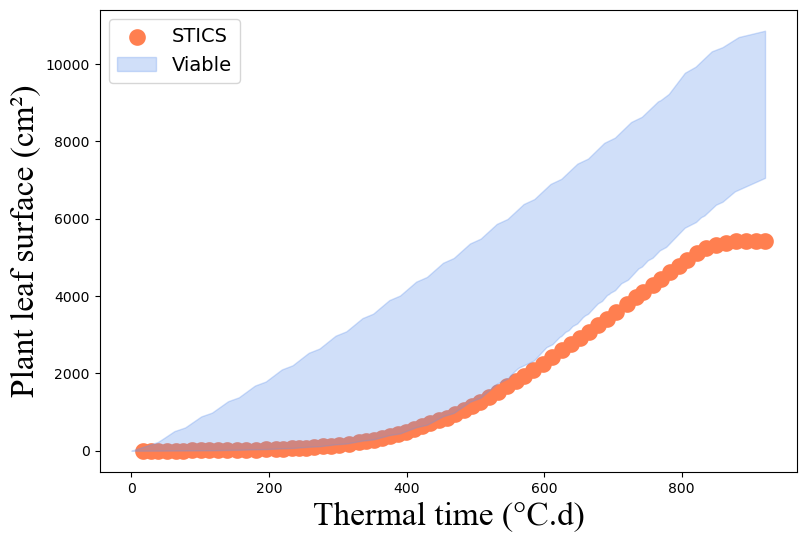

In [9]:
from openalea.archicrop.cereal_axis import bell_shaped_dist
from openalea.archicrop.viability import resolve_organ_growth, compute_skew
import math

leaf_area_plant_pot = leaf_area_plant_pot[:index_end_veg_pot+2]
thermal_time_pot = thermal_time_pot[:index_end_veg_pot+2]
spl = splrep(thermal_time_pot, leaf_area_plant_pot)

fig, ax1 = plt.subplots(figsize=(9, 6))
ax1.scatter(thermal_time_pot, leaf_area_plant_pot, linewidth=6, color="coral", label="STICS")

first = True
mins = np.zeros(len(np.arange(0,thermal_time_pot[index_end_veg_pot+1])))
maxs = np.zeros(len(np.arange(0,thermal_time_pot[index_end_veg_pot+1])))
print(len(maxs))

for n,l in d.items():
    for p,r in l:
        ligulochron = p * 1.6
        starts = []
        ends = []
        for i in range(n):
            start = i * p
            end = start + ligulochron
            starts.append(start)
            ends.append(end)
        
        la_starts = splev(starts, spl)
        la_ends = splev(ends, spl)
        
        leaf_areas = resolve_organ_growth(n, 1.6, la_ends)
        leaf_areas_norm = [la/max(leaf_areas) for la in leaf_areas]
    
        skews = []
        for rank in range(1, n+1):
            if r != rank/n and leaf_areas[rank-1] > 0:
                skew = compute_skew(rank=rank, nb_phy=n, rmax=r, leaf_areas=leaf_areas_norm)
                if 1e-10 < skew < 1.0:
                    skews.append(skew)
    
        for pot_factor in [1.0,1.1,1.2,1.3,1.4,1.5]:
            
            shapes = []
            for skew in skews:
                bell_shaped_leaf_areas = bell_shaped_dist(leaf_area_plant_pot[-1] * pot_factor, n, r, skew)
                viable = True
                for i,bs in enumerate(bell_shaped_leaf_areas):
                    if bs < leaf_areas[i]: 
                        viable = False
                        break
                if viable:
                    shapes.append(bell_shaped_leaf_areas)
            
            for j,shape in enumerate(shapes):
                S = []
                tt = np.arange(max(ends))
                # print(len(tt))
                for k,t in enumerate(tt):
                    sum_temp = 0
                    for i,(s,e) in enumerate(zip(starts,ends)):
                        if s <= t < e:
                            sum_temp += (t-s)/(e-s) * shape[i]
                        elif t >= e:
                            sum_temp += shape[i]
                    if sum_temp < mins[k] or mins[k] == 0:
                        mins[k] = sum_temp
                    if sum_temp > maxs[k]:
                        maxs[k] = sum_temp
                    S.append(sum_temp)
            
                # if first:
                #     ax1.plot(tt, S, color='cornflowerblue', linestyle='dotted', alpha=0.2, label="Viable")
                #     first = False
                # else:
                #     ax1.plot(tt, S, color='cornflowerblue', linestyle='dotted', alpha=0.2)

ax1.fill_between(tt, mins, maxs, alpha = 0.3, color='cornflowerblue', label="Viable")
ax1.set_xlabel("Thermal time (°C.d)", fontsize=24, fontname="Times New Roman")
ax1.set_ylabel("Plant leaf surface (cm²)", fontsize=24, fontname="Times New Roman")
ax1.legend(fontsize=14)


today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True)  
plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/result_2_viable_morphospace_dynamics.png")
plt.show()